# This script plot the full Verlauf from the pixel 1 to 6

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

In [3]:
pixel_file = ""  # Enter your file path/folder path in this place

In [4]:
df = pd.read_csv(pixel_file)

In [5]:
df

,Timestamp[s],Labels,Temperature [C],Cycle Number,Isc[mA/cm2],Voc [V],I_MPP [mA/cm2],V_MPP [V],FF,PCE [%],Rs,Rp
0,0.0,20250915_155022_Thermal_Cycling_px2_Light_forw...,19.53,1.0,4.937160,0.953226,4.633936,-0.816935,0.804386,16.943223,0.012750,3.122933
1,150.0,20250915_155252_Thermal_Cycling_px2_Light_forw...,44.65,1.0,4.802896,0.911290,4.282387,-0.775000,0.758277,14.854091,0.015682,1.855676
2,270.0,20250915_155452_Thermal_Cycling_px2_Light_forw...,56.80,1.0,4.683517,0.879839,4.196867,-0.733065,0.746607,13.769754,0.018545,3.081143
3,390.0,20250915_155652_Thermal_Cycling_px2_Light_forw...,62.72,1.0,4.619135,0.858871,4.168583,-0.701613,0.737221,13.090150,0.016421,8.283231
4,510.0,20250915_155852_Thermal_Cycling_px2_Light_forw...,65.96,1.0,4.507244,0.848387,4.148870,-0.680645,0.738491,12.638890,0.016596,4.750925
...,...,...,...,...,...,...,...,...,...,...,...,...
1345,273151.0,20250918_194253_Thermal_Cycling_px2_Light_forw...,67.91,50.0,3.087216,0.764516,1.700544,-0.544355,0.392208,4.143131,0.059057,0.467503
1346,273270.0,20250918_194452_Thermal_Cycling_px2_Light_forw...,66.35,50.0,3.108346,0.754032,1.685234,-0.544355,0.391402,4.105829,0.059575,0.454781
1347,273390.0,20250918_194652_Thermal_Cycling_px2_Light_forw...,64.70,50.0,3.068332,0.764516,1.738395,-0.523387,0.387867,4.072208,0.061145,0.635515
1348,273510.0,20250918_194852_Thermal_Cycling_px2_Light_forw...,64.54,50.0,3.127230,0.764516,1.577837,-0.575806,0.380007,4.066275,0.060360,0.510977


In [6]:
timestamp_h = df["Timestamp[s]"]/3600
temperature = df["Temperature [C]"]


In [7]:
MPP = -df["I_MPP [mA/cm2]"] * df["V_MPP [V]"]

(37.0, 55.0)

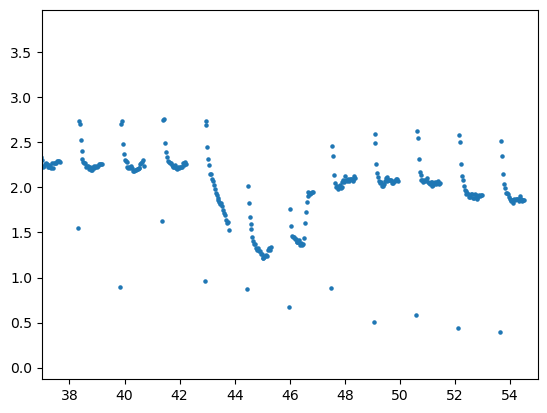

In [8]:
plt.scatter(timestamp_h, MPP, s=5)
plt.xlim(37, 55)


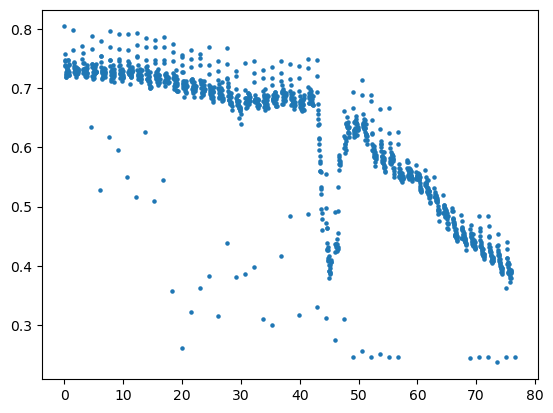

In [9]:
plt.scatter(timestamp_h, df["FF"], s=5)
#plt.xlim(35, 55)

Do another calculation

In [10]:
from plot_module.solsim_analyzer import solarSimulator

In [11]:
#folderPath = ""  # Enter your file path/folder path in this place
folderPath = ""  # Enter your file path/folder path in this place

In [12]:
analyzer = solarSimulator(folderPath=folderPath)
analyzer.loadFolderData_Cycling()

Line 6: # Measured Temperature: 75.36 C
[-0.0396222  -0.27512013 -0.49131192 -0.60366598 -0.73875713 -0.86772473
 -0.94465605 -0.98435483 -1.04909101 -1.11744787 -1.14743748 -1.15048231
 -1.22201313 -1.24501855 -1.24145881 -1.22766125 -1.28083609 -1.29779158
 -1.28143556 -1.28984774 -1.29717719 -1.26745825 -1.25779337 -1.26570171
 -1.27653074 -1.25411566 -1.25143733 -1.28332324 -1.26995387 -1.23938642
 -1.21120656 -1.20112086 -1.18221519 -1.16930862 -1.17532402 -1.17258095
 -1.15618283 -1.11453006 -1.10007329 -1.10034776 -1.05567962 -1.02720616
 -1.00921615 -0.99868364 -0.95655636 -0.93327294 -0.91292834 -0.8866603
 -0.84247882 -0.8284334  -0.81162092 -0.77864257 -0.74889144 -0.72776312
 -0.69678    -0.66424038 -0.63026335 -0.60608821 -0.57079978 -0.530146
 -0.49851588 -0.46889306 -0.42844168 -0.39060205 -0.35762907 -0.32173031
 -0.27651689 -0.24050702 -0.20564229 -0.16548266 -0.12322707 -0.08182182
  0.00328213]
Line 6: # Measured Temperature: 75.36 C
20250917_154852_Thermal_Cycling_p

In [13]:
print(analyzer.cycleNum)
cycle_number = [29, 30, 31, 32, 33]

[1.0, 1.0, 3.0, 4.0, 4.0]


In [14]:
currents_smooth = []
window = 7
for i in range (0, len(analyzer.PCE)):
    currents_smooth.append(np.convolve(analyzer.currents[i], np.ones(window)/window, mode='same'))

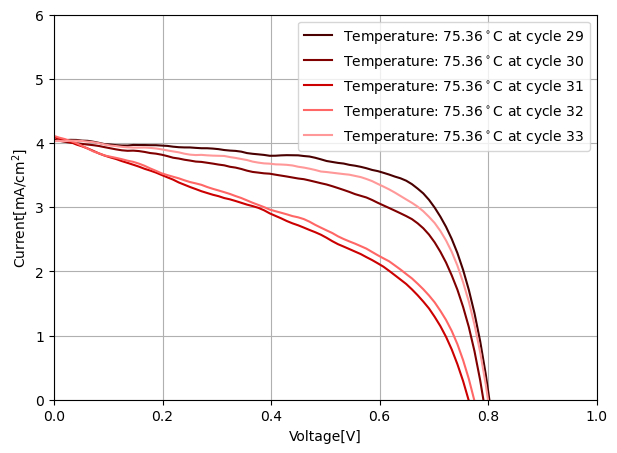

In [ ]:
red_gradient = ["#4A0000", "#800000", "#CC0000", "#FF6666", "#FF9999"]

plt.figure(figsize = (7,5), dpi = 300)
for i in range (0, len(analyzer.PCE)):
    #plt.plot(analyzer.voltages[i], analyzer.currents[i], label = f"Temperature: {analyzer.temperature[i]}$^\circ$C at cycle {cycle_number[i]}")
    #plt.title(f"Temperature: {analyzer.temperature[i]} at cycle numbrer {analyzer.cycleNum[i]}")
    plt.plot(-analyzer.voltages[i], currents_smooth[i], color = red_gradient[i], label = f"Temperature: {analyzer.temperature[i]}$^\circ$C at cycle {cycle_number[i]}")
plt.xlim(0, 1)
plt.xlabel("Voltage[V]")
plt.ylabel("Current[mA/cm$^2$]")
plt.ylim(0, 6)
plt.legend()
plt.grid()


In [16]:
for i in range (0, len(analyzer.PCE)):
    if analyzer.cycleNum[i] == 32:
        plt.figure(figsize = (7,5))
        plt.plot(analyzer.voltages[i], analyzer.currents[i])
        plt.title(f"Temperature: {analyzer.temperature[i]}")
        plt.xlim(-1, 0)
        plt.ylim(0, 10)
plt.show()